# Integrated Assignment AESM extraction processes

In [3]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
from scipy.spatial import Voronoi, voronoi_plot_2d
from shapely.geometry import Polygon

#### import location data

In [4]:
data=pd.read_csv('Sampling points_Location_LA.csv', sep=';', decimal=',') 
data.head()   

data=data.dropna()
display(data)

,Name,Latitude,Longitude
0,MM_11,-7.168107,37.622178
1,LMW_8,-7.167952,37.622218
2,MM_10,-7.167996,37.622132
3,MM_9,-7.167856,37.622126
4,MM_8,-7.167826,37.622080
...,...,...,...
83,LA_2024_5,-7.167420,37.623840
84,LA_2024_6,-7.167420,37.624100
85,LA_2024_7,-7.167260,37.624320
86,LA_2024_8,-7.167110,37.624610


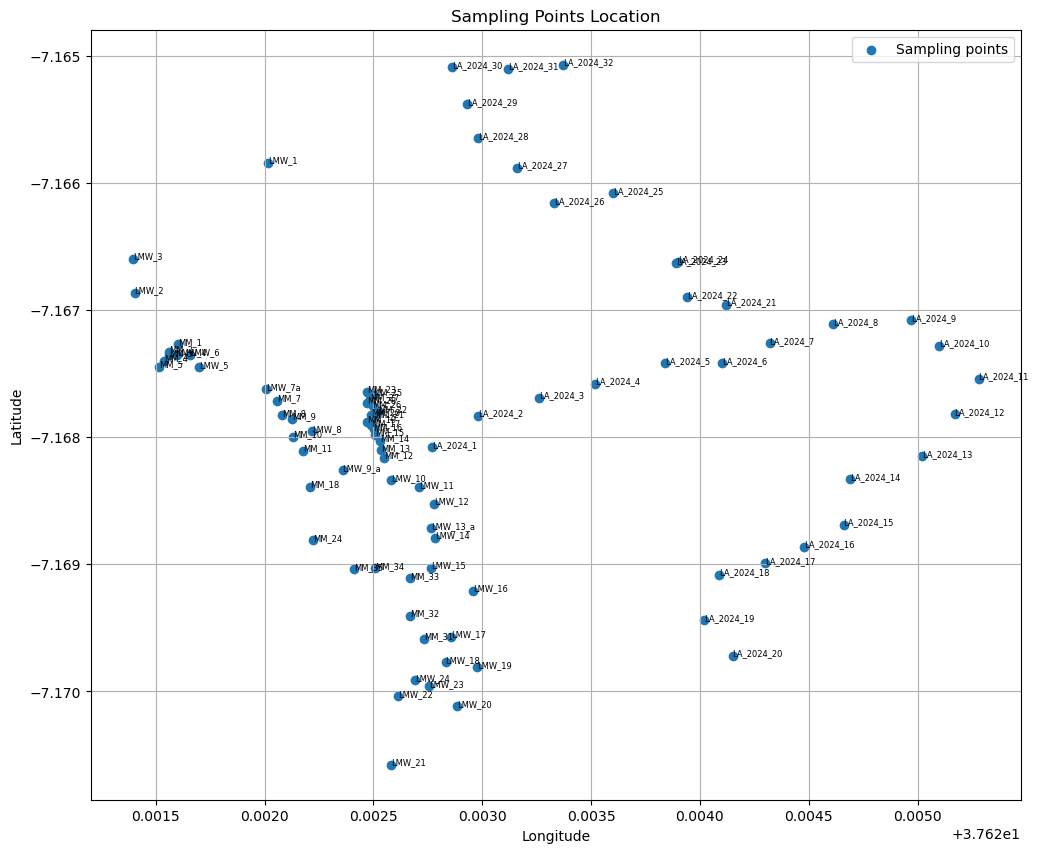

<Figure size 640x480 with 0 Axes>

In [5]:
plt.figure(figsize=(12, 10))
plt.scatter(data['Longitude'], data['Latitude'], label='Sampling points')

for i, row in data.iterrows():
    plt.text(row['Longitude'], row['Latitude'], row['Name'], fontsize=6)

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Sampling Points Location')
plt.legend()
plt.grid()
plt.show()
plt.savefig('sampling_points_location.png')

## oke, move to plot later influence of everypoint; see areas of influence

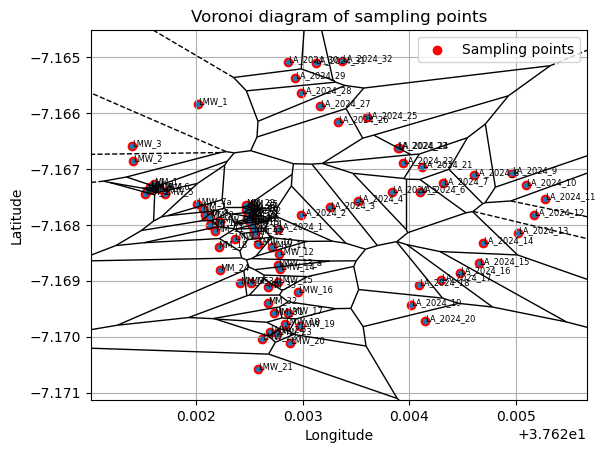

In [25]:
points = data[['Longitude', 'Latitude']].values

vor = Voronoi(points)

fig, ax = plt.subplots()

voronoi_plot_2d(vor, ax=ax, show_vertices=False, line_colors='black')

ax.scatter(data['Longitude'], data['Latitude'], color='red', label='Sampling points')
for i, row in data.iterrows():
    plt.text(row['Longitude'], row['Latitude'], row['Name'], fontsize=6)


plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Voronoi diagram of sampling points")
plt.grid()
plt.legend()
plt.savefig('voronoi_diagram_sampling_points_infinite.png')
plt.show()

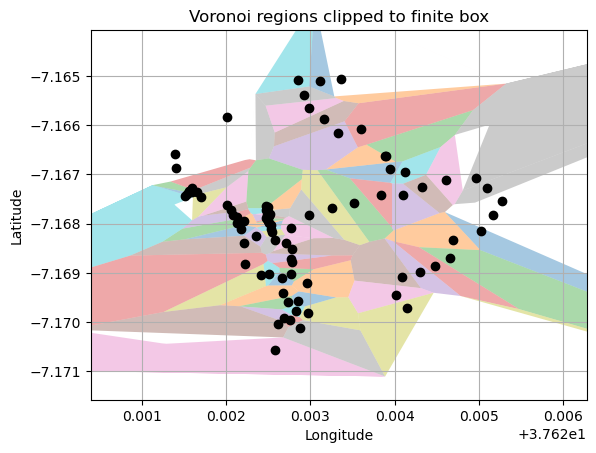

In [26]:
def voronoi_finite_polygons_2d(vor, radius=None):
    """Reconstruct infinite Voronoi regions in a 2D diagram to finite
    regions. 

    Parameters
    ----------
    vor : Voronoi
        The object returned by scipy.spatial.Voronoi.
    radius : float, optional
        Distance at which “points at infinity” are placed.  If None the
        routine chooses something based on the data extent.

    Returns
    -------
    regions : list of list of int
        Each sub‑list is a sequence of vertex indices defining one polygon.
    vertices : ndarray, shape (M,2)
        Coordinates of the original + extra (clipped) vertices.

    """
    if vor.points.shape[1] != 2:
        raise ValueError("Requires 2D input")

    new_regions = []
    new_vertices = vor.vertices.tolist()

    center = vor.points.mean(axis=0)
    if radius is None:
        # use np.ptp for compatibility with numpy>=2.0
        radius = np.ptp(vor.points, axis=0).max()*2

    # map of all ridges for each point
    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    # reconstruct regions
    for p1, region in enumerate(vor.point_region):
        vertices = vor.regions[region]
        if -1 not in vertices:
            new_regions.append(vertices)
            continue
        ridges = all_ridges[p1]
        new_region = [v for v in vertices if v != -1]
        for p2, v1, v2 in ridges:
            if v2 < 0:
                v1, v2 = v2, v1
            if v1 >= 0 and v2 >= 0:
                continue
            t = vor.points[p2] - vor.points[p1]
            t /= np.linalg.norm(t)
            n = np.array([-t[1], t[0]])
            midpoint = vor.points[[p1, p2]].mean(axis=0)
            direction = np.sign(np.dot(midpoint - center, n)) * n
            far_point = vor.vertices[v2] + direction * radius
            new_vertices.append(far_point.tolist())
            new_region.append(len(new_vertices) - 1)
        new_regions.append(new_region)
    return new_regions, np.asarray(new_vertices)

# create finite polygons and display
regions_finite, vertices_finite = voronoi_finite_polygons_2d(vor, radius=0.0000001)
fig, ax = plt.subplots()
for region in regions_finite:
    polygon = vertices_finite[region]
    ax.fill(*zip(*polygon), alpha=0.4)
ax.plot(points[:,0], points[:,1], 'ko')
ax.set_title('Voronoi regions clipped to finite box')
ax.set_xlim(points[:,0].min()-0.001, points[:,0].max()+0.001)
ax.set_ylim(points[:,1].min()-0.001, points[:,1].max()+0.001)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.grid()
plt.savefig('voronoi_finite_polygons_finite_areas.png')
plt.show()


In [29]:
regions = []
for region_index in vor.point_region:
    vertices = vor.regions[region_index]
    
    if -1 in vertices or len(vertices) == 0:
        continue
        
    polygon = Polygon(vor.vertices[vertices])
    regions.append(polygon)

areas = [poly.area for poly in regions]

print(np.shape(areas))
print(areas)

#data['Voronoi_area'] = areas

(76,)
[9.290924941574675e-08, 3.661025990750257e-08, 1.570101891612557e-07, 2.5911202722580677e-08, 9.375465111166433e-08, 4.831740486199832e-08, 1.9613257576852405e-07, 9.541839646585515e-08, 1.0897773132807114e-07, 1.5610308675875376e-08, 2.463464162794367e-09, 4.242141878177864e-08, 2.1427733795646072e-07, 4.588263706808159e-09, 3.7401788044504005e-07, 5.8770799996536436e-08, 4.986798481037117e-08, 1.865413283859925e-07, 8.942560072059844e-08, 2.9766159265593094e-08, 7.33246317156211e-08, 9.753331208067422e-07, 6.084357825348757e-07, 3.179645762703161e-07, 3.696020725766282e-08, 9.200248857826122e-08, 3.72696948126315e-07, 5.993707101557337e-08, 1.53961643678342e-07, 8.034463504969323e-08, 2.5817637440100215e-07, 5.970525175467163e-08, 6.578624281447818e-08, 2.7317439838962533e-08, 1.8083182711213655e-08, 1.7641526641540922e-08, 1.5556105790093206e-08, 1.1188983562958713e-08, 5.966130702664049e-09, 1.561820422265719e-08, 1.0485054657751987e-08, 5.780316396955142e-09, 3.2147140110370